# PRCP-1025-FlightPricePrediction

# Step.1 Problem definition :

 Objective :- Flight ticket prices change frequently depending on airline, timing, stops, route, and other factors. 
######The goal of this project is : 
* To analyze the flight dataset.
* To identify factors affecting ticket prices.
* To build a machine learning model that predicts flight prices accurately.

Problem type :- This is a Regression Problem because the target variable (Price) is continuous numerical data.

Business use case :-

This project can help:
* Customers plan journeys at better prices
* Airlines analyze pricing trends
* Travel companies estimate future ticket prices

### Attribute Information

1. Airline:
   Name of airline company.

2. Date_of_Journey:
   Date on which journey starts.

3. Source:
   Starting city of flight.

4. Destination:
   Ending city of flight.

5. Route:
   Travel route between source and destination.

6. Arrival_Time:
   Time at which flight reaches destination.

7. Duration:
   Total travel duration.

8. Total_Stops:
   Number of stops during journey.

9. Additional_Info:
   Extra information about journey.

10. Price:
   Flight ticket price (Target Variable).

# Step.2 Data collection :

The dataset used for this project was obtained from the provided source link. It contains flight related information such as Airline, Date_of_Journey
, source, destination, route, arrival_time, price.

The dataset was downloaded in a compressed (ZIP) format and extracted locally. 

The dataset consists of multiple features (independent variables) and one target variable (price), which is used for prediction.

The data was loaded into a Jupyter Notebook environment using the pandas library for further analysis and preprocessing.

In [1]:
# import libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
%matplotlib inline

In [2]:
# For .xlsx files, pandas needs the package:

!pip install openpyxl

In [3]:
# Load dataset (whhich is in xlsx form)

df=pd.read_excel("Flight_Fare.xlsx")

In [4]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


# Basic checks:-

In [5]:
# First 5 rows

df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [6]:
# Last 5 rows

df.tail()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [7]:
# check number of rows and columns

df.shape

(10683, 11)

In [8]:
# column names

df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [9]:
# #statistical summary-mean, min, max, standard deviation, helps to detect outliers .

df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [10]:
# Check data type of columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [11]:
df.duplicated().sum()

np.int64(220)

# Step.3 Data Preprocessing

In [12]:
# check missing value
# Route -> 1 missing value, Total_Stops -> 1 missing value

df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [13]:
# Remove missing value

df.dropna(inplace=True)

In [14]:
# Verify missing value again

df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [15]:
# Check duplicate rows

df.duplicated().sum()

np.int64(220)

In [16]:
# Remove duplicate rows

df.drop_duplicates(inplace=True)

In [17]:
# Creating a backup copy of dataset for EDA visualization
# so that original columns remain available after preprocessing

df_original = df.copy()

In [18]:
# Convert Date_of_jouney    Extract:  day, month
# Journey_Day

df["Journey_day"] = pd.to_datetime(
    df["Date_of_Journey"],
    format="%d/%m/%Y"
).dt.day

In [19]:
df["Journey_month"] = pd.to_datetime(
    df["Date_of_Journey"],
    format="%d/%m/%Y"
).dt.month

In [20]:
# Drop original column

df.drop("Date_of_Journey", axis=1, inplace=True)

In [21]:
# Convert Dept_Time  -- Extract: departure hour, departure minute

df["Dep_hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour

df["Dep_min"] = pd.to_datetime(df["Dep_Time"]).dt.minute

C:\Users\vijay\AppData\Local\Temp\ipykernel_20596\4186213355.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dep_hour"] = pd.to_datetime(df["Dep_Time"]).dt.hour
C:\Users\vijay\AppData\Local\Temp\ipykernel_20596\4186213355.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dep_min"] = pd.to_datetime(df["Dep_Time"]).dt.minute


In [22]:
# Drop original column

df.drop("Dep_Time", axis=1, inplace=True)

In [23]:
# Convert Arrival_Time -- Arrival_hour, Arrival_min

df["Arrival_hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour

df["Arrival_min"] = pd.to_datetime(df["Arrival_Time"]).dt.minute

C:\Users\vijay\AppData\Local\Temp\ipykernel_20596\534944868.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Arrival_hour"] = pd.to_datetime(df["Arrival_Time"]).dt.hour
C:\Users\vijay\AppData\Local\Temp\ipykernel_20596\534944868.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Arrival_min"] = pd.to_datetime(df["Arrival_Time"]).dt.minute


In [24]:
# Drop original column

df.drop("Arrival_Time", axis=1, inplace=True)

In [25]:
# Process Duration column --- convert duration into hours, minutes

duration = list(df["Duration"])
for i in range(len(duration)):
    if len(duration[i].split()) != 2:
        if "h" in duration[i]:
            duration[i] = duration[i] + " 0m"
        else:
            duration[i] = "0h " + duration[i]

In [26]:
duration_hours = []
duration_mins = []
for i in range(len(duration)):
    
    duration_hours.append(
        int(duration[i].split(sep="h")[0])
    )
    
    duration_mins.append(
        int(duration[i].split(sep="m")[0].split()[-1])
    )

In [27]:
df["Duration_hours"] = duration_hours

df["Duration_mins"] = duration_mins

In [28]:
# Drop original column

df.drop("Duration", axis=1, inplace=True)

In [29]:
# Convert Total_Stops

df["Total_Stops"] = df["Total_Stops"].map({
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
})

In [30]:
# Handle categorical columns

df = pd.get_dummies(df, drop_first=True)

In [31]:
df.isnull().sum()

Total_Stops                                     0
Price                                           0
Journey_day                                     0
Journey_month                                   0
Dep_hour                                        0
                                               ..
Additional_Info_In-flight meal not included     0
Additional_Info_No Info                         0
Additional_Info_No check-in baggage included    0
Additional_Info_No info                         0
Additional_Info_Red-eye flight                  0
Length: 166, dtype: int64

 Data Preprocessing Completed
* Missing values were handled.
* Duplicate rows were removed.
* Date and time columns were converted into useful numerical features.
* Duration column was processed into hours and minutes.
* Categorical columns were converted using One Hot Encoding.

# Step. 4 EDA (Exploratory Data Analysis)
EDA is the process of analyzing and understanding the dataset using statistics and visualizations.
It helps identify patterns, relationships, trends, and important insights in the data before building machine learning models.

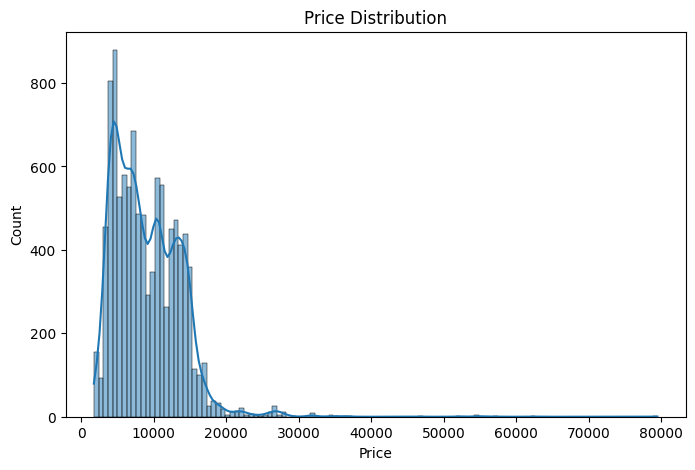

In [32]:
# Price distribution - Understand how price is distributed

# Insight: Most flight prices are concentrated in lower to medium price range.

plt.figure(figsize=(8,5))
sns.histplot(df_original["Price"], kde=True)
plt.title("Price Distribution")

plt.show()

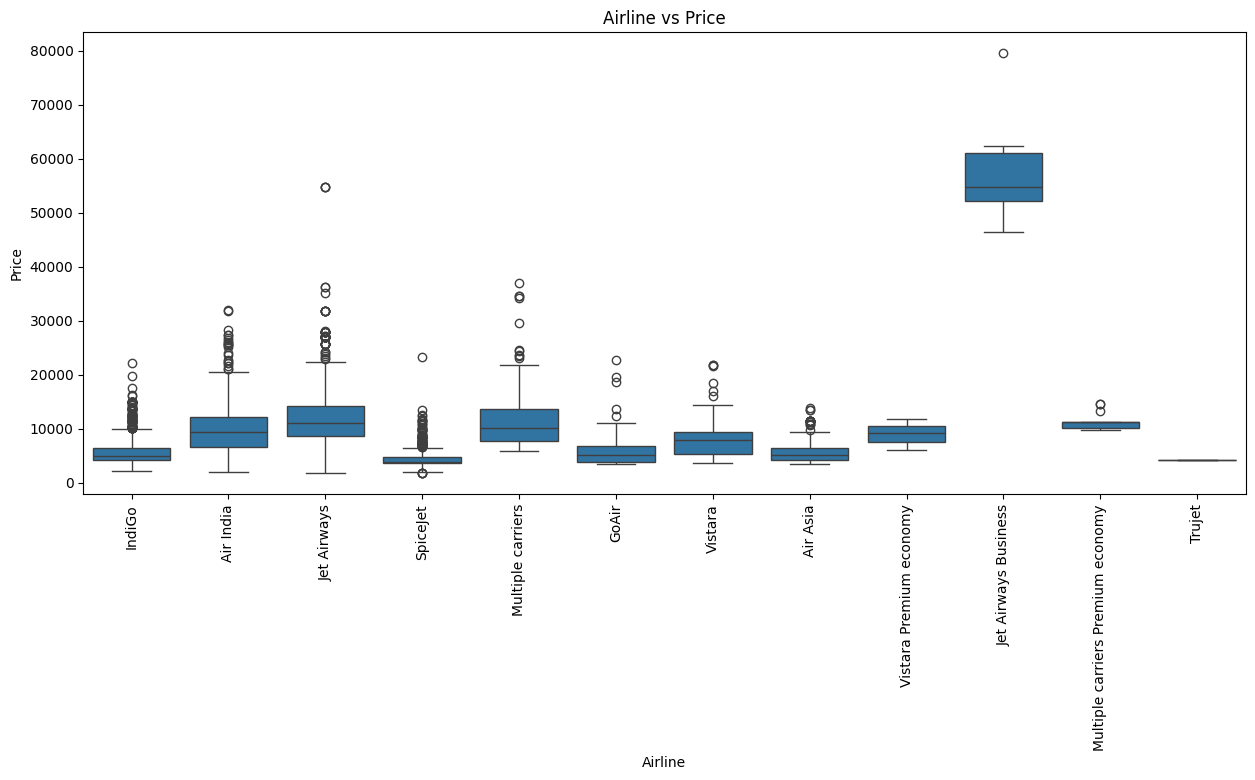

In [33]:
# Airline vs Price - Check which airline is expensive.
# Some airlines have higher average ticket prices compared to others.

plt.figure(figsize=(15,6))
sns.boxplot(x="Airline", y="Price", data=df_original)
plt.xticks(rotation=90)      # Rotate the x-axis labels by 90 degrees.
plt.title("Airline vs Price")

plt.show()

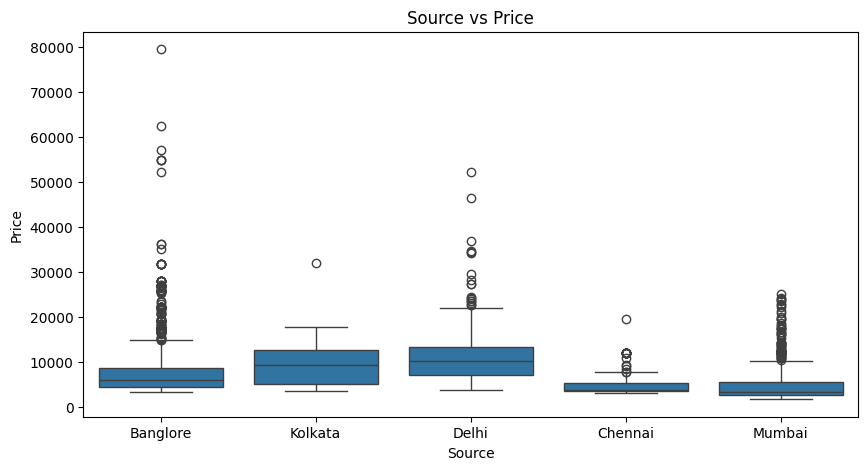

In [34]:
# Source vs Price
# Insight: Ticket prices vary depending on source city.

plt.figure(figsize=(10,5))
sns.boxplot(x="Source", y="Price", data=df_original)
plt.title("Source vs Price")

plt.show()

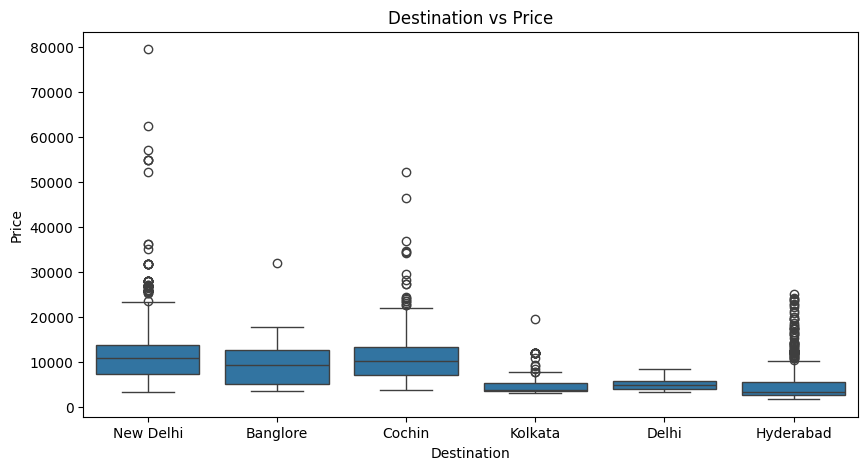

In [35]:
# Destination vs Price
# Insight: Destination city affects flight pricing significantly.

plt.figure(figsize=(10,5))
sns.boxplot(x="Destination", y="Price", data=df_original)
plt.title("Destination vs Price")

plt.show()

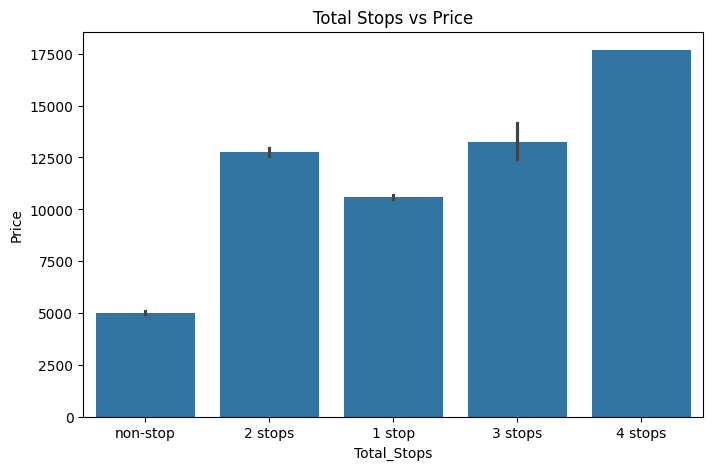

In [36]:
# Total stops vs price
# Insight: Flights with more stops generally have higher prices.

plt.figure(figsize=(8,5))
sns.barplot(x="Total_Stops", y="Price", data=df_original)
plt.title("Total Stops vs Price")

plt.show()

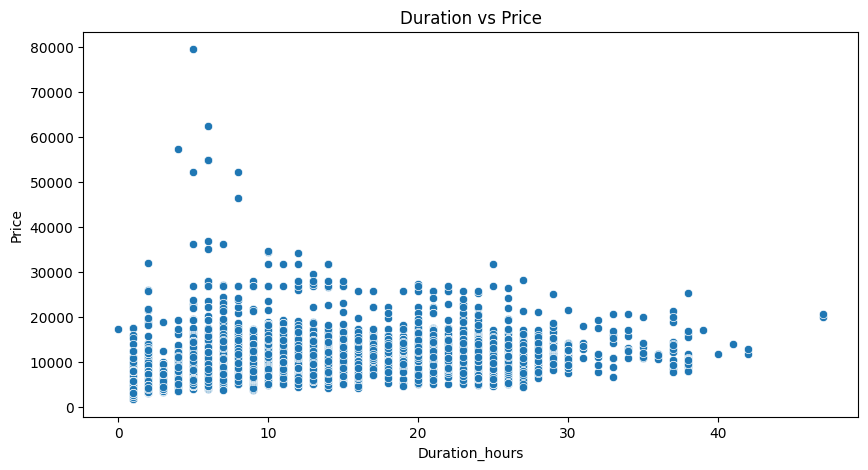

In [37]:
# Duration vs price
# Insight: Longer duration flights tend to have higher ticket prices.

plt.figure(figsize=(10,5))
sns.scatterplot(x="Duration_hours", y="Price",data=df)
plt.title("Duration vs Price")

plt.show()

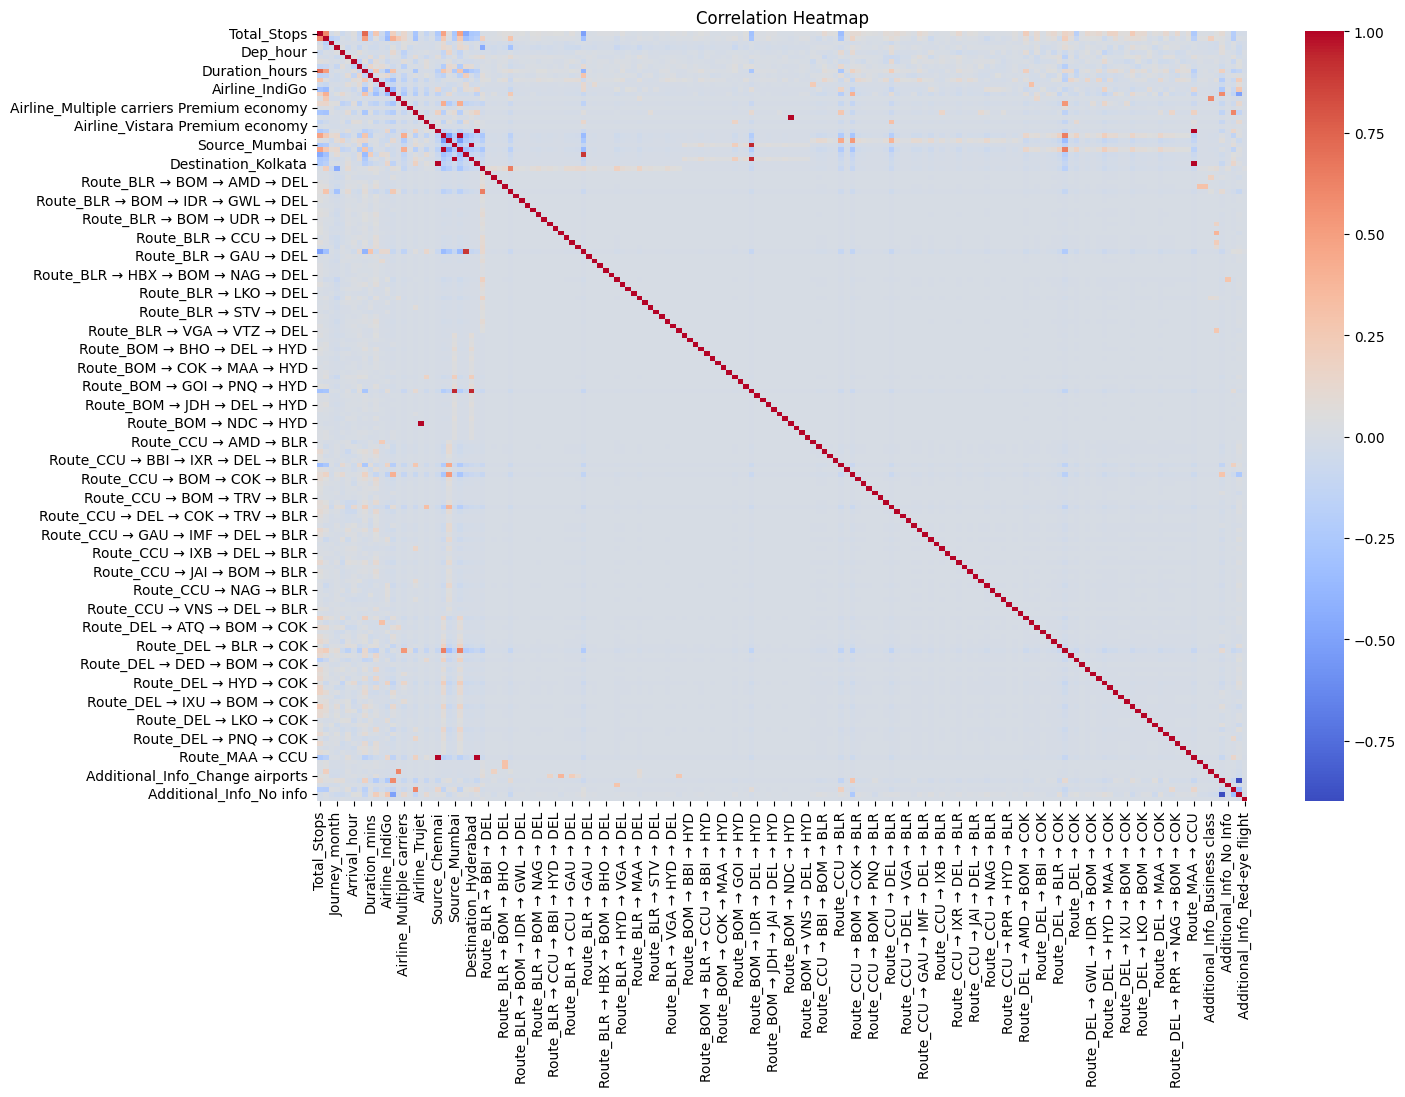

In [38]:
# Correlation heatmap
# Insight: Heatmap shows relationships between numerical features.

plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")

plt.show()

<Axes: xlabel='Duration_hours', ylabel='Price'>

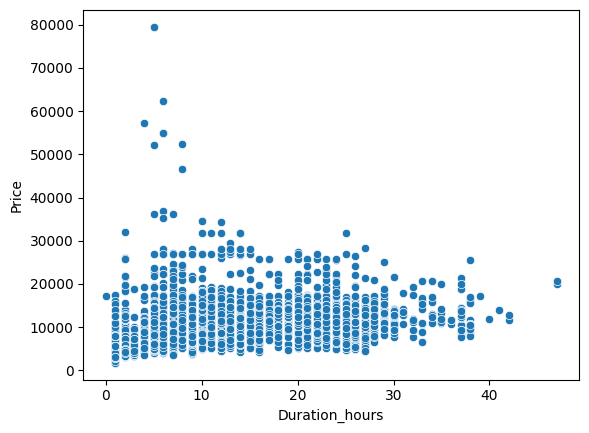

In [39]:
# Scatter plot : it helps show the relationship between two numerical variables.

sns.scatterplot(x="Duration_hours", y="Price", data=df)

 EDA Conclusion

 Flight prices are affected by:
 - Airline
 - Total Stops
 - Duration
 - Source and Destination

 Flights with longer duration and more stops
 generally have higher prices.

# Step.5 Model building
Model building is the process of training machine learning algorithms using the prepared dataset to make predictions.
In this project, models learn patterns from flight data to predict ticket prices accurately.

In [40]:
# define X and y --- separate features and target 

X=df.drop('Price',axis=1)      # Features -- X (input)
y=df['Price']                  # Target -- y (output)  we want to predict

In [41]:
# Train-test split

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [42]:
# Feature scaling

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [43]:
# import model

from sklearn.linear_model import LinearRegression

In [44]:
# Create model object

model=LinearRegression()

In [45]:
# Train model (fit)

model.fit(X_train,y_train)     # model learns-- slope(m), intercept(c)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [46]:
# make prediction

y_pred=model.predict(X_test)

# Step.6 Model evaluation


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [48]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print(mae)
print(mse)
print(rmse)
print(r2)

1541.3814178350717
5917504.663729581
2432.5921696267915
0.7161905887252642


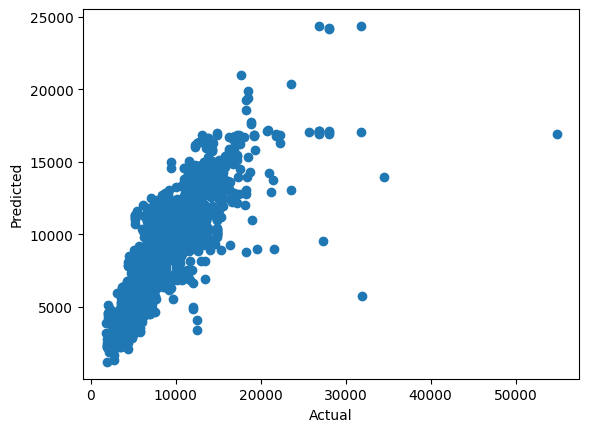

In [49]:
# Compare actual vs predicted

plt.scatter(y_test,y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

In [50]:
# Check coefficient  
# Tells which feature affects price more.

print(model.coef_)
print(model.intercept_)

[ 8.12644294e+02 -4.91442792e+02 -3.67324767e+02  6.18294537e+01
 -3.89990034e+01 -1.93436524e+01  7.17256026e+01 -2.48261282e+01
  1.63453961e+01  5.69013376e+02 -5.41411986e+01  9.98613890e+01
  2.58842917e+03  1.03644375e+03  8.94982372e+02  8.52083880e+01
 -4.90865578e+01 -1.24371357e+01  3.27199906e+02  5.83858082e+01
 -8.60469093e+01  1.81606900e+02  5.16131820e+01 -2.19895178e+02
  1.81606900e+02 -3.93521830e+02 -2.19895178e+02 -8.60469093e+01
  3.05335756e+02  6.76716886e+00 -7.67721923e+01  4.25380869e+01
  1.48912423e+02  4.25409205e+02  4.79474859e+01  1.08501775e+01
  1.86762054e+01  5.56587034e+01  9.84533846e+01 -3.51309901e+00
 -5.36247813e+01 -9.86763610e+00 -5.68434189e-14  1.04524317e+01
 -3.95748995e+01 -4.83222996e+01 -3.23867147e+02  1.22860107e+01
 -1.00961866e+01 -3.27408269e+01  1.04966359e+01 -2.84217094e-14
 -2.47980318e+02 -2.00071787e+01 -2.96369447e+01 -1.99608247e+01
 -7.46717982e+01  3.67489798e+01  7.61878021e+01 -4.91620782e+01
  5.43640664e-01 -5.52294

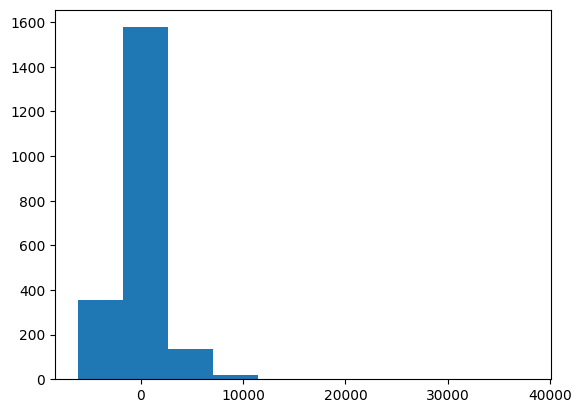

In [51]:
residuals=y_test-y_pred
plt.hist(residuals)
plt.show()

* Model Evaluation

* The Linear Regression model achieved an R2 Score of 0.716,
* which means the model explains around 71.6% variance in flight prices.

* The model performance is reasonably good for prediction.

## Random forest model


In [52]:
# Import model

from sklearn.ensemble import RandomForestRegressor

In [53]:
# Create model

rf = RandomForestRegressor(random_state=42)

In [54]:
# Train model

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [55]:
# predict model

rf_pred = rf.predict(X_test)

In [63]:
# Evaluate model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_rf = mean_absolute_error(y_test, rf_pred)
mse_rf = mean_squared_error(y_test, rf_pred)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, rf_pred)

print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE: 626.5375025921282
MSE: 2014545.555037436
RMSE: 1419.346876220692
R2 Score: 0.903380390814773


### Model comparision report


Two machine learning models were trained:
1. Linear Regression
2. Random Forest Regressor

Performance:
Linear Regression          |Random Forest Regressor
---------------------------|------------------------
  R2 Score = 0.716         |     R2 Score = 0.903
                           |


Conclusion:
Random Forest Regressor performed significantly better than Linear Regression.
It captures complex relationships in the dataset more effectively.

Therefore, Random Forest Regressor is selected as the best model for production.

### Report on Challenges Faced

During the development of the Flight Fare Prediction project, several challenges were encountered in the dataset and preprocessing stages. The following are the key challenges and the techniques used to handle them:

1. Missing Values in Dataset

Some columns such as Route and Total_Stops contained missing values.

Technique Used:
Missing rows were removed using dropna().

Reason:
The number of missing values was very small, so removing them did not affect model performance and ensured data quality.

2. Duplicate Records

The dataset contained duplicate rows which could bias the model.

Technique Used:
Duplicates were removed using drop_duplicates().

Reason:
Removing duplicates helps improve model accuracy by preventing repeated information during training.

3. Complex Date and Time Features

Columns like Date_of_Journey, Dep_Time, and Arrival_Time were in string format and not directly usable for machine learning.

Technique Used:
Extracted meaningful features such as day, month, hour, and minute using pandas datetime functions.

Reason:
Machine learning models require numerical input, so converting time-based data into numerical features improves model performance.

4. Duration Column Formatting Issue

The Duration column had inconsistent formats such as 2h 50m, 19h, and 50m.

Technique Used:
Separated hours and minutes into two numerical columns.

Reason:
Standardizing format ensures consistency and helps the model interpret travel time correctly.

5. Categorical Data Handling

Columns like Airline, Source, and Destination contained categorical text data.

Technique Used:
Applied One Hot Encoding using pd.get_dummies().

Reason:
Machine learning models cannot directly process text data, so encoding was necessary to convert it into numerical format.

6. Model Performance Improvement

Initial Linear Regression model gave moderate performance.

Technique Used:
Applied Random Forest Regressor for better prediction.

Reason:
Random Forest handles non-linear relationships better and improves prediction accuracy.

#### Final conclusion
Despite these challenges, proper data preprocessing and model selection helped build an accurate flight price prediction model with strong performance.